In [2]:
import os, warnings
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
import h5py
from collections import defaultdict

warnings.filterwarnings("ignore")
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)
sns.set_style("ticks")

print("Libraries loaded.")


Libraries loaded.


In [3]:
DATA_DIR  = "/mnt/172/wh/25-12/spatial/raw/pertubmap"
SLIDES    = ["GSM5808054", "GSM5808055", "GSM5808056", "GSM5808057"]
OUT_DIR   = "/root/code/nicheformer/output/0525"
os.makedirs(OUT_DIR, exist_ok=True)

print("Loading per-slide data (each slide has 2000 genes, not just the 1053-intersection)...")
print("=" * 70)

adatas = {}
for slide in SLIDES:
    path = os.path.join(DATA_DIR, f"{slide}_data.h5")
    with h5py.File(path, "r") as f:
        X  = f["X"][:]                       # (n_cells, 2000)
        genes   = [g.decode() for g in f["gene"][:]]
        perturb = np.array([p.decode() for p in f["perturbation"][:]])
        pos     = f["pos"][:]                 # (2, n_cells)
        tissue  = np.array([t.decode() for t in f["tissue"][:]])

    adata = sc.AnnData(
        X    = csr_matrix(X, dtype=np.float32),
        obs  = pd.DataFrame({
            "perturbation": perturb,
            "tissue":       tissue,
            "slide":        slide,
            "x":            pos[0, :].astype(np.float32),
            "y":            pos[1, :].astype(np.float32),
        }),
        var  = pd.DataFrame(index=genes),
    )
    adata.obsm["spatial"] = pos.T.astype(np.float32)
    adata.layers["raw"]   = adata.X.copy()
    adatas[slide] = adata
    uniq_p  = sorted(adata.obs["perturbation"].unique())
    uniq_t  = sorted(adata.obs["tissue"].unique())
    print(f"  {slide}: {adata.n_obs} cells, perturbations={uniq_p}, tissues={uniq_t}")

print(f"\nEach slide has 2000 genes in its panel (union: 3335, intersection: 1053).")
print(f"We use per-slide panels (2000 genes) to maximize coverage.")


Loading per-slide data (each slide has 2000 genes, not just the 1053-intersection)...
  GSM5808054: 1903 cells, perturbations=['Jak2', 'KP', 'None', 'Tgfbr2', 'periphery'], tissues=['normal', 'tumor']
  GSM5808055: 1872 cells, perturbations=['Ifngr2', 'KP', 'None', 'Tgfbr2', 'periphery'], tissues=['normal', 'tumor']
  GSM5808056: 1233 cells, perturbations=['Ifngr2', 'KP', 'None', 'periphery'], tissues=['normal', 'tumor']
  GSM5808057: 1355 cells, perturbations=['KP', 'None', 'Tgfbr2', 'periphery'], tissues=['normal', 'tumor']

Each slide has 2000 genes in its panel (union: 3335, intersection: 1053).
We use per-slide panels (2000 genes) to maximize coverage.


In [4]:
print("=" * 70)
print("Are the perturbation-target genes in the CosMx panel?")
print("=" * 70)

QUERY = ["Tgfbr2", "Ifngr2", "Jak2", "Kras", "Trp53",
         "Krt8", "Krt18", "Krt19", "Krt20", "Krt80",
         "Jun", "Fos", "Smad2", "Smad3", "Smad4",
         "Stat1", "Stat3", "Stat5a", "Egfr", "Met"]

for gene in QUERY:
    presence = {s: (gene in adatas[s].var_names) for s in SLIDES}
    slides_with = [s for s, v in presence.items() if v]
    status = f"FOUND in {slides_with}" if slides_with else "NOT IN PANEL"
    print(f"  {gene:12s}: {status}")


Are the perturbation-target genes in the CosMx panel?
  Tgfbr2      : NOT IN PANEL
  Ifngr2      : NOT IN PANEL
  Jak2        : NOT IN PANEL
  Kras        : NOT IN PANEL
  Trp53       : FOUND in ['GSM5808056', 'GSM5808057']
  Krt8        : FOUND in ['GSM5808054', 'GSM5808055', 'GSM5808056', 'GSM5808057']
  Krt18       : FOUND in ['GSM5808054', 'GSM5808055', 'GSM5808056', 'GSM5808057']
  Krt19       : FOUND in ['GSM5808054', 'GSM5808055', 'GSM5808056', 'GSM5808057']
  Krt20       : FOUND in ['GSM5808054', 'GSM5808055', 'GSM5808056', 'GSM5808057']
  Krt80       : FOUND in ['GSM5808054', 'GSM5808055', 'GSM5808056', 'GSM5808057']
  Jun         : FOUND in ['GSM5808054', 'GSM5808055', 'GSM5808056', 'GSM5808057']
  Fos         : FOUND in ['GSM5808056', 'GSM5808057']
  Smad2       : NOT IN PANEL
  Smad3       : NOT IN PANEL
  Smad4       : NOT IN PANEL
  Stat1       : FOUND in ['GSM5808054', 'GSM5808055']
  Stat3       : NOT IN PANEL
  Stat5a      : NOT IN PANEL
  Egfr        : FOUND in ['GSM5


Perturbation distribution per slide


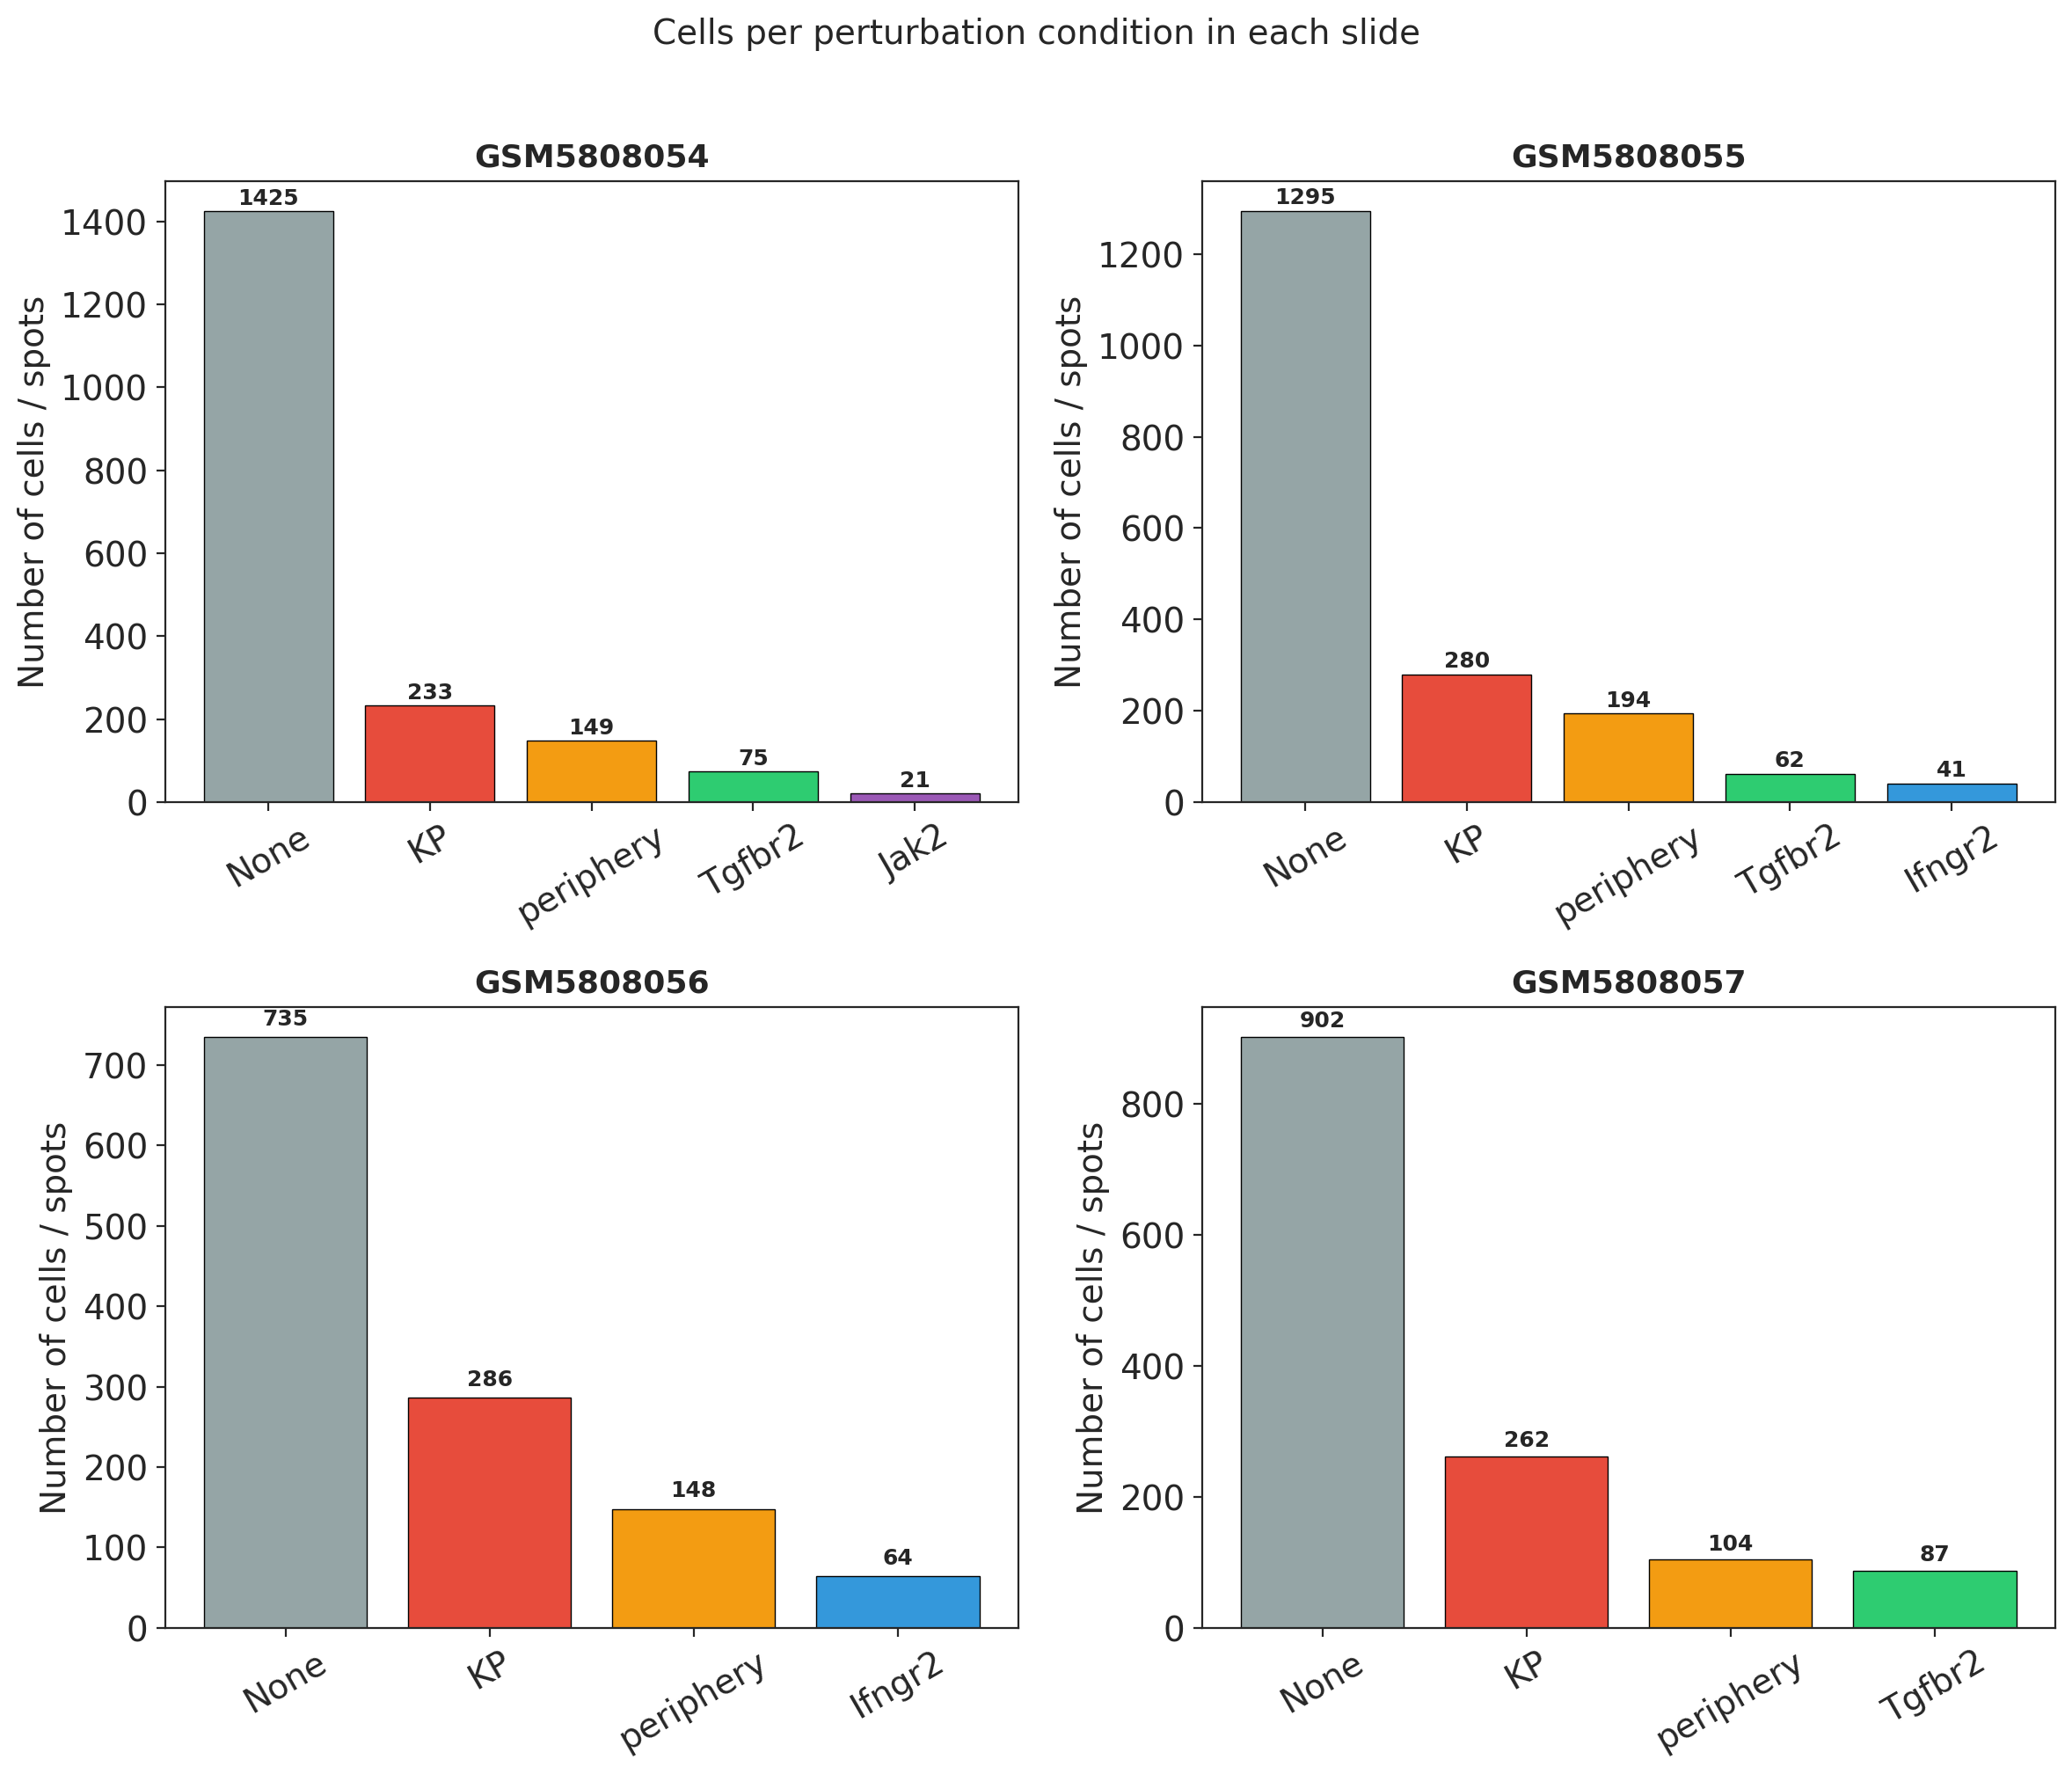

   -> perturbation_distribution.png saved


In [5]:
print("\n" + "=" * 70)
print("Perturbation distribution per slide")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

pert_colors = {
    "KP":         "#E74C3C",
    "Tgfbr2":     "#2ECC71",
    "Ifngr2":     "#3498DB",
    "Jak2":       "#9B59B6",
    "None":       "#95A5A6",
    "periphery":  "#F39C12",
}

for i, slide in enumerate(SLIDES):
    ax = axes[i]
    vc = adatas[slide].obs["perturbation"].value_counts()
    bars = ax.bar(vc.index, vc.values,
                  color=[pert_colors.get(p, "#333") for p in vc.index],
                  edgecolor="black", linewidth=0.5)
    ax.set_title(slide, fontsize=13, fontweight="bold")
    ax.set_ylabel("Number of cells / spots")
    ax.tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                str(val), ha="center", fontsize=9, fontweight="bold")

fig.suptitle("Cells per perturbation condition in each slide", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "perturbation_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print("   -> perturbation_distribution.png saved")


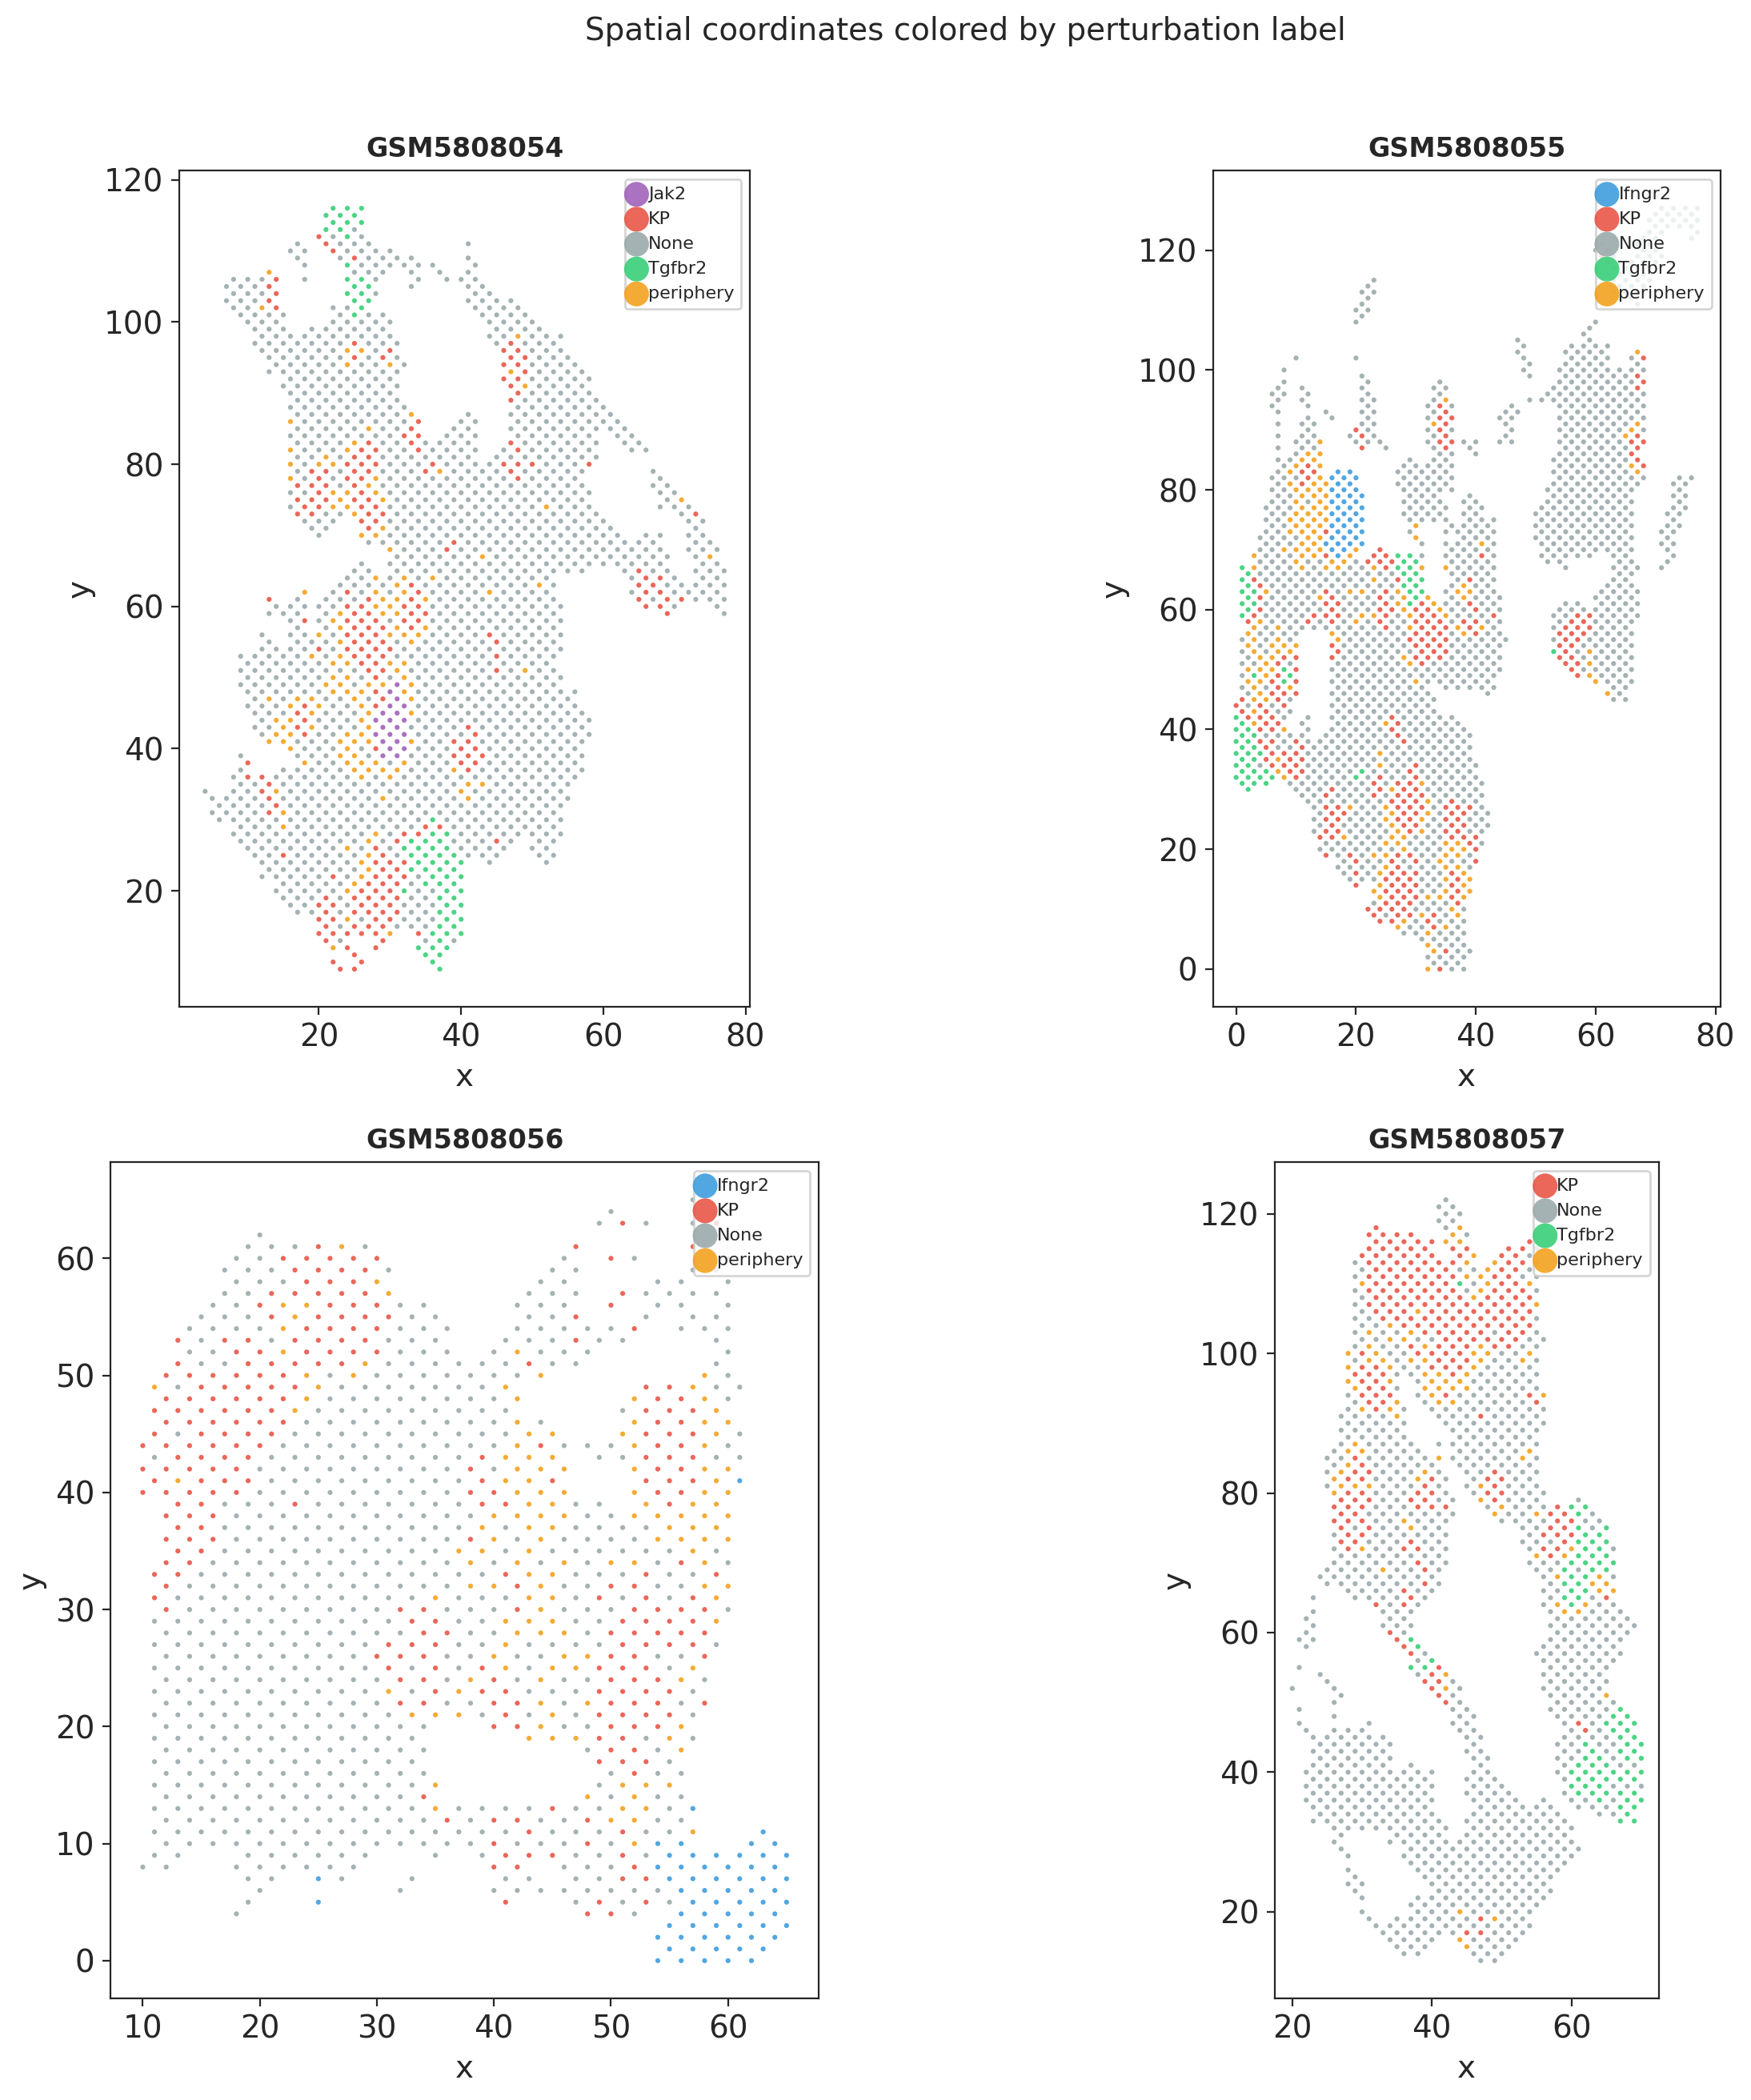

   -> spatial_by_perturbation.png saved


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 13))
axes = axes.flatten()

for i, slide in enumerate(SLIDES):
    ax = axes[i]
    adata = adatas[slide]
    xy = adata.obsm["spatial"]
    for pert in sorted(adata.obs["perturbation"].unique()):
        mask = adata.obs["perturbation"] == pert
        ax.scatter(xy[mask, 0], xy[mask, 1],
                   c=pert_colors.get(pert, "#333333"),
                   label=pert, s=5, alpha=0.85, rasterized=True,
                   edgecolors="none")
    ax.set_title(slide, fontsize=12, fontweight="bold")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.legend(markerscale=5, fontsize=8, loc="upper right", frameon=True)
    ax.set_aspect("equal")

fig.suptitle("Spatial coordinates colored by perturbation label", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "spatial_by_perturbation.png"), dpi=150, bbox_inches="tight")
plt.show()
print("   -> spatial_by_perturbation.png saved")


Keratin genes in all panels: ['Krt8', 'Krt18', 'Krt19', 'Krt20', 'Krt80']


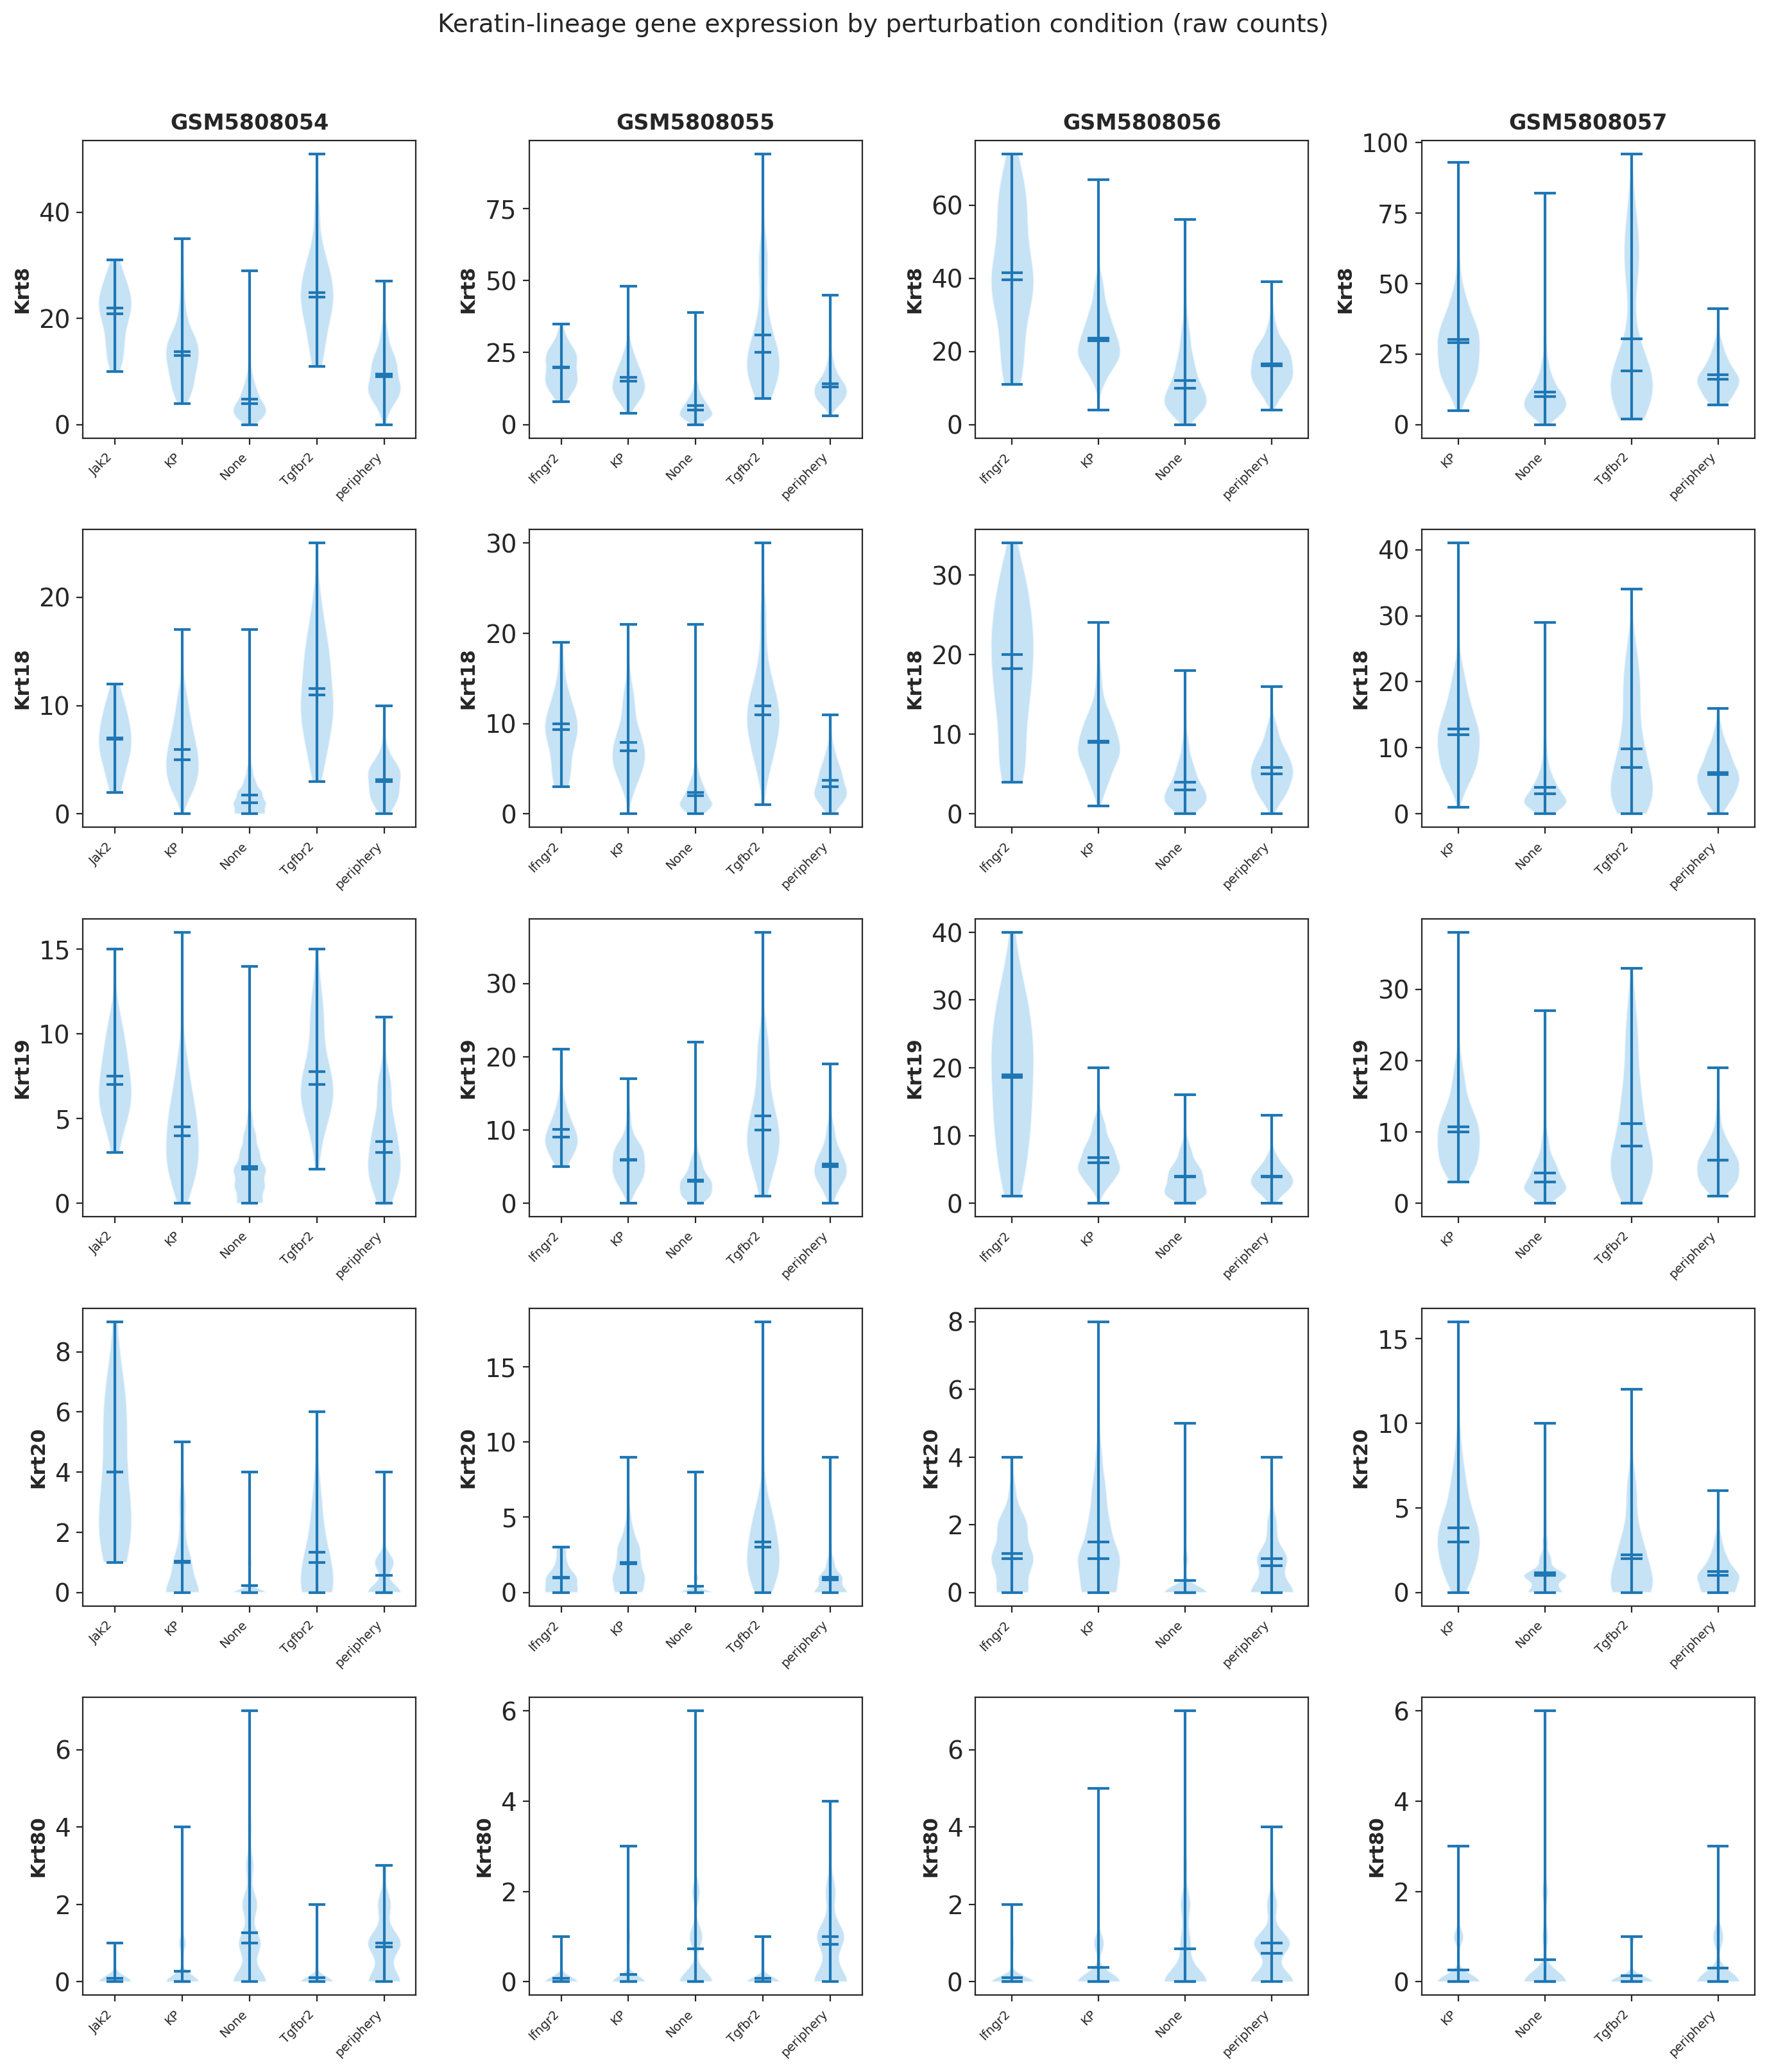

   -> krt_expression_by_pert.png saved


In [7]:
KRTS = ["Krt8", "Krt18", "Krt19", "Krt20", "Krt80"]
# Verify all present
KRTS = [g for g in KRTS if all(g in adatas[s].var_names for s in SLIDES)]
print(f"Keratin genes in all panels: {KRTS}")

fig, axes = plt.subplots(len(KRTS), len(SLIDES), figsize=(len(SLIDES)*3.5, len(KRTS)*3.2))

for row, krt in enumerate(KRTS):
    for col, slide in enumerate(SLIDES):
        ax = axes[row, col] if len(KRTS) > 1 else axes[col]
        adata = adatas[slide]
        krt_idx = list(adata.var_names).index(krt)
        expr = adata.X[:, krt_idx].toarray().flatten()
        pert_series = adata.obs["perturbation"].values

        pert_order = sorted(set(pert_series))
        data_by_pert = {p: expr[pert_series == p] for p in pert_order}
        parts = ax.violinplot([data_by_pert[p] for p in pert_order],
                              positions=range(len(pert_order)),
                              showmeans=True, showmedians=True)
        for pc in parts["bodies"]:
            pc.set_facecolor("#AED6F1")
            pc.set_alpha(0.7)
        ax.set_xticks(range(len(pert_order)))
        ax.set_xticklabels(pert_order, rotation=45, ha="right", fontsize=7)
        ax.set_ylabel(krt, fontsize=11, fontweight="bold")
        if row == 0:
            ax.set_title(slide, fontsize=12, fontweight="bold")

fig.suptitle("Keratin-lineage gene expression by perturbation condition (raw counts)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "krt_expression_by_pert.png"), dpi=150, bbox_inches="tight")
plt.show()
print("   -> krt_expression_by_pert.png saved")


Pseudobulk summary (first 10 rows):
        slide perturbation             pathway   gene  mean_expr  n_cells
0  GSM5808054         Jak2     KP marker (Krt)   Krt8  20.904760       21
1  GSM5808054         Jak2     KP marker (Krt)  Krt18   6.904762       21
2  GSM5808054         Jak2     KP marker (Krt)  Krt19   7.523810       21
3  GSM5808054         Jak2     KP marker (Krt)  Krt20   4.000000       21
4  GSM5808054         Jak2     KP marker (Krt)  Krt80   0.095238       21
5  GSM5808054         Jak2             AP-1 TF    Jun   0.380952       21
6  GSM5808054         Jak2  Growth factor rec.  Bmpr2   0.428571       21
7  GSM5808054           KP     KP marker (Krt)   Krt8  13.763948      233
8  GSM5808054           KP     KP marker (Krt)  Krt18   5.961373      233
9  GSM5808054           KP     KP marker (Krt)  Krt19   4.502146      233


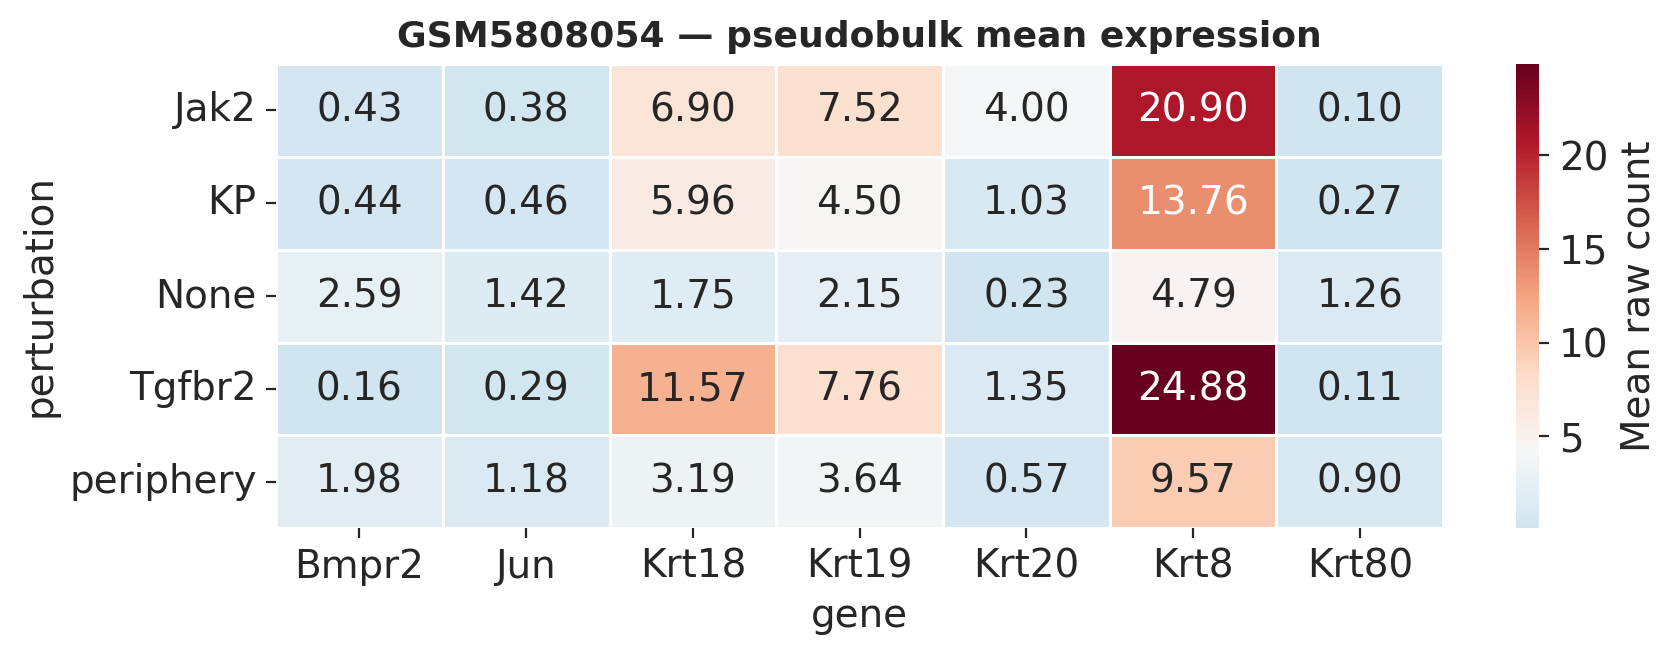

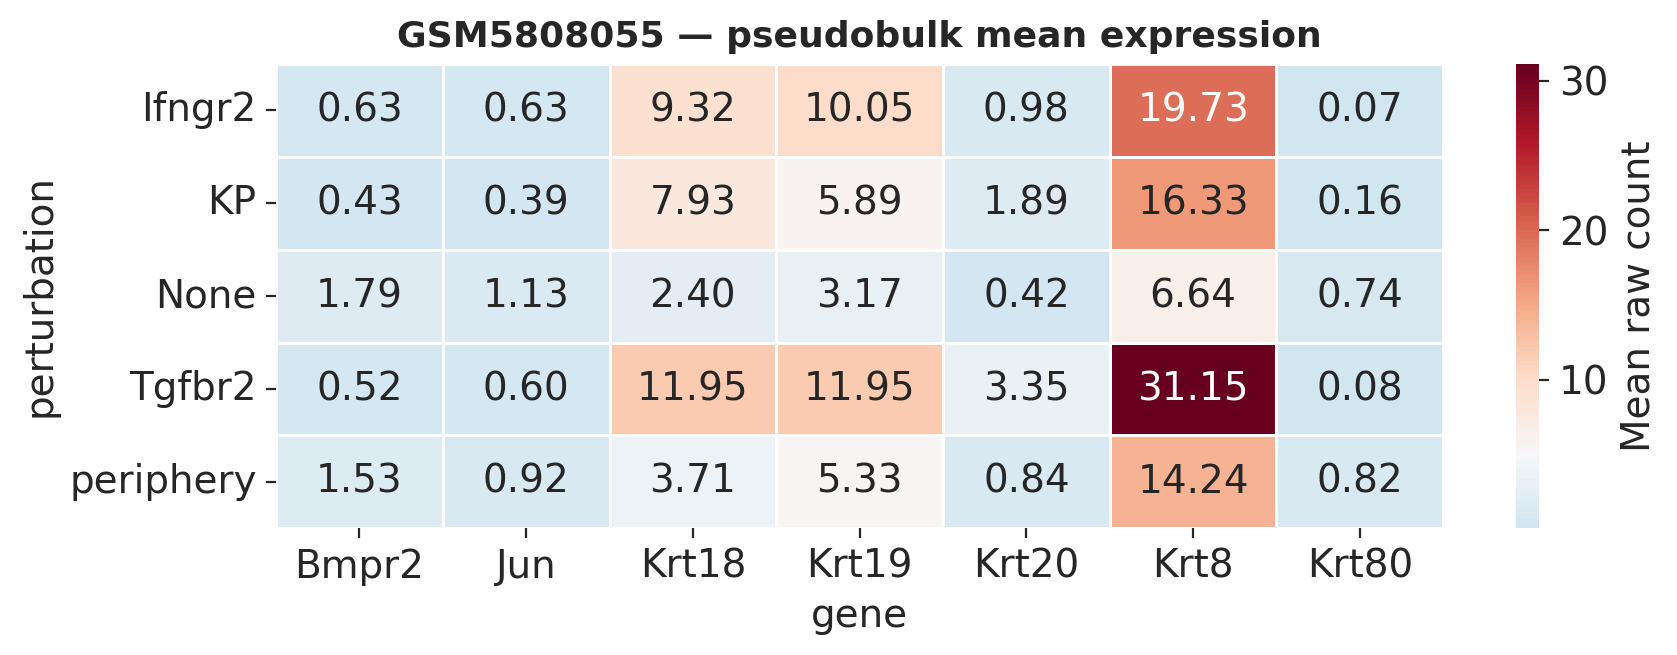

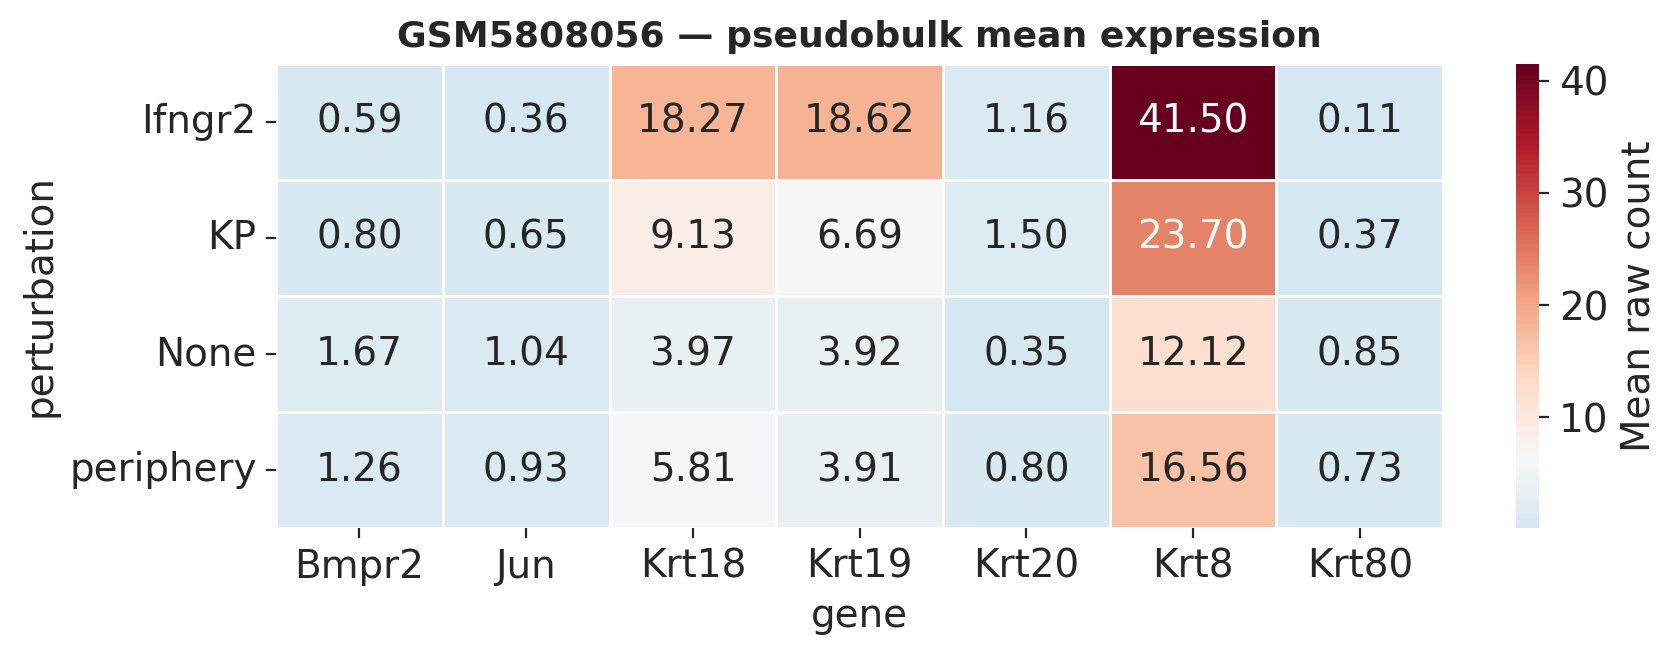

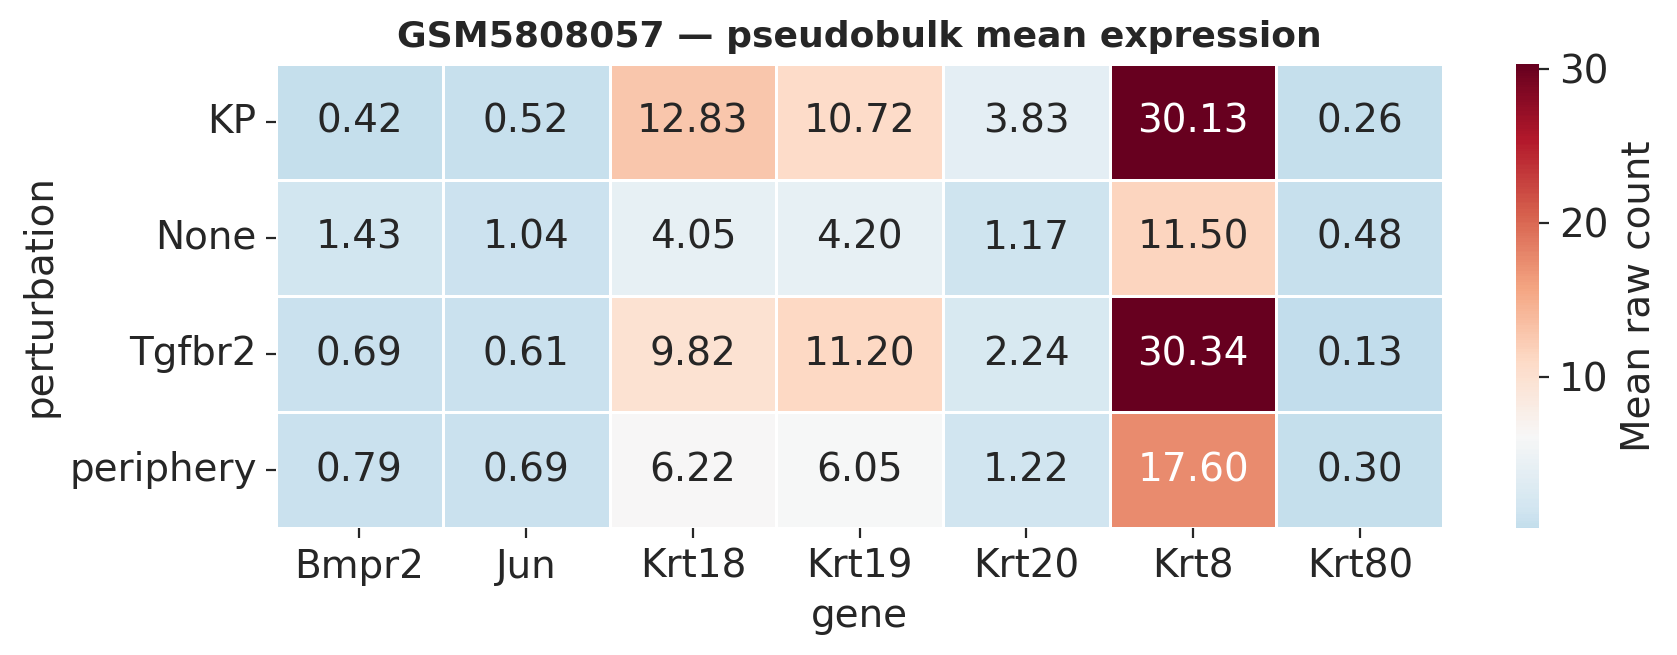

   -> heatmap_*.png saved


In [8]:
PATHWAY_GENES = {
    "KP marker (Krt)":     ["Krt8", "Krt18", "Krt19", "Krt20", "Krt80"],
    "AP-1 TF":             ["Jun", "Fos"],
    "TGFb signaling":      ["Smad2", "Smad3", "Smad4"],
    "JAK/STAT":            ["Stat1", "Stat3", "Stat5a"],
    "Growth factor rec.":  ["Egfr", "Met", "Bmpr2"],
}

# Filter to available
available_pathway = {}
for name, genes in PATHWAY_GENES.items():
    avail = [g for g in genes if all(g in adatas[s].var_names for s in SLIDES)]
    if avail:
        available_pathway[name] = avail

# Build pseudobulk summary
records = []
for slide in SLIDES:
    adata = adatas[slide]
    for pert in sorted(adata.obs["perturbation"].unique()):
        mask = adata.obs["perturbation"] == pert
        n_cells = mask.sum()
        for pathway, genes in available_pathway.items():
            for gene in genes:
                idx = list(adata.var_names).index(gene)
                mean_expr = adata.X[mask, idx].mean()
                records.append({
                    "slide": slide, "perturbation": pert,
                    "pathway": pathway, "gene": gene,
                    "mean_expr": mean_expr, "n_cells": n_cells,
                })

df_pathway = pd.DataFrame(records)
print("Pseudobulk summary (first 10 rows):")
print(df_pathway.head(10))

# Heatmap per slide
for slide in SLIDES:
    df_slide = df_pathway[df_pathway["slide"] == slide]
    pivot = df_slide.pivot_table(
        index="perturbation", columns="gene",
        values="mean_expr", aggfunc="mean"
    ).fillna(0)

    fig, ax = plt.subplots(figsize=(max(9, len(pivot.columns)*1.0),
                                    max(3.5, len(pivot)*0.7)))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdBu_r",
                center=pivot.values.mean(), ax=ax,
                linewidths=0.5, cbar_kws={"label": "Mean raw count"})
    ax.set_title(f"{slide} — pseudobulk mean expression", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"heatmap_{slide}.png"), dpi=150, bbox_inches="tight")
    plt.show()

print("   -> heatmap_*.png saved")


In [9]:
print("=" * 70)
print("DEG analysis: perturbation vs 'None' (control) per slide")
print("=" * 70)

all_degs = {}
for slide in SLIDES:
    adata = adatas[slide].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata.layers["logNor"] = adata.X.copy()

    pert_types = [p for p in sorted(adata.obs["perturbation"].unique())
                  if p not in ("None", "periphery")]

    for pert in pert_types:
        try:
            sub = adata[adata.obs["perturbation"].isin(["None", pert])].copy()
            sc.tl.rank_genes_groups(sub, groupby="perturbation",
                                    reference="None", groups=[pert],
                                    method="wilcoxon", pts=True)
            degs = sub.uns["rank_genes_groups"]
            names  = np.array(degs["names"][pert])
            scores = np.array(degs["scores"][pert])
            pvals  = np.array(degs["pvals_adj"][pert])
            logfcs = np.array(degs["logfoldchanges"][pert])
            mask   = ~np.isnan(scores) & (pvals < 0.05)
            sig = pd.DataFrame({
                "gene": names[mask], "score": scores[mask],
                "logFC": logfcs[mask], "padj": pvals[mask],
            }).sort_values("score", ascending=False)
            sig["perturbation"] = pert
            sig["slide"] = slide
            all_degs[f"{slide}_{pert}"] = sig
            print(f"  {slide} | {pert:8s}: {len(sig):4d} DEGs (padj<0.05)")
        except Exception as e:
            print(f"  {slide} | {pert:8s}: FAILED — {e}")

# Save
if all_degs:
    df_all_degs = pd.concat(all_degs.values(), ignore_index=True)
    df_all_degs.to_csv(os.path.join(OUT_DIR, "degs_per_slide.csv"), index=False)

print(f"\nTotal DEG results: {len(df_all_degs)} rows -> degs_per_slide.csv")


DEG analysis: perturbation vs 'None' (control) per slide
  GSM5808054 | Jak2    :  541 DEGs (padj<0.05)
  GSM5808054 | KP      : 1009 DEGs (padj<0.05)
  GSM5808054 | Tgfbr2  :  980 DEGs (padj<0.05)
  GSM5808055 | Ifngr2  :  620 DEGs (padj<0.05)
  GSM5808055 | KP      :  932 DEGs (padj<0.05)
  GSM5808055 | Tgfbr2  :  690 DEGs (padj<0.05)
  GSM5808056 | Ifngr2  :  707 DEGs (padj<0.05)
  GSM5808056 | KP      :  696 DEGs (padj<0.05)
  GSM5808057 | KP      :  760 DEGs (padj<0.05)
  GSM5808057 | Tgfbr2  :  767 DEGs (padj<0.05)

Total DEG results: 7702 rows -> degs_per_slide.csv


In [10]:
print("=" * 70)
print("Top 15 DEGs per perturbation per slide")
print("=" * 70)

for key in sorted(all_degs.keys()):
    deg_df = all_degs[key]
    print(f"\n--- {key} ({len(deg_df)} DEGs) ---")
    top = deg_df.head(15)
    for _, row in top.iterrows():
        print(f"  {row['gene']:20s} | score={row['score']:8.3f}  "
              f"logFC={row['logFC']:7.3f}  padj={row['padj']:.2e}")

# Cross-slide comparison: which DEGs are shared?
print("\n" + "=" * 70)
print("Cross-slide DEG overlap")
print("=" * 70)

# For each perturbation type, check gene overlap across slides
for pert in ["KP", "Tgfbr2", "Ifngr2", "Jak2"]:
    slide_genes = {}
    for slide in SLIDES:
        key = f"{slide}_{pert}"
        if key in all_degs:
            slide_genes[slide] = set(all_degs[key]["gene"].values)

    if len(slide_genes) >= 2:
        slides_list = list(slide_genes.keys())
        print(f"\n  {pert}:")
        for s in slides_list:
            print(f"    {s}: {len(slide_genes[s])} DEGs")
        # Intersection
        from functools import reduce
        common = reduce(lambda a, b: a & b, slide_genes.values())
        print(f"    Shared across all {len(slides_list)} slides: {len(common)} genes")
        if len(common) > 0 and len(common) <= 30:
            print(f"    Genes: {sorted(common)}")
    else:
        print(f"\n  {pert}: only present in {len(slide_genes)} slide(s)")

print("\nDone.")


Top 15 DEGs per perturbation per slide

--- GSM5808054_Jak2 (541 DEGs) ---
  Lypd8                | score=   7.874  logFC=  7.917  padj=7.54e-13
  Lgals2               | score=   7.872  logFC=  6.864  padj=7.54e-13
  Ugt2b34              | score=   7.869  logFC=  8.313  padj=7.54e-13
  Gsta1                | score=   7.868  logFC=  6.936  padj=7.54e-13
  Plac8                | score=   7.867  logFC=  4.340  padj=7.54e-13
  Dmbt1                | score=   7.858  logFC=  7.429  padj=7.54e-13
  Clca1                | score=   7.857  logFC=  8.338  padj=7.54e-13
  Sptssb               | score=   7.848  logFC=  7.324  padj=7.54e-13
  Spp1                 | score=   7.843  logFC=  4.418  padj=7.54e-13
  Tspan8               | score=   7.838  logFC=  3.463  padj=7.54e-13
  Gsta4                | score=   7.830  logFC=  4.834  padj=7.54e-13
  Ifi27l2b             | score=   7.826  logFC=  6.176  padj=7.54e-13
  Car2                 | score=   7.817  logFC=  4.444  padj=7.54e-13
  Apob         